# 用布尔网络建模脑动力学与向下因果

## 复现论文：Bertacchini et al. (2022) *Modelling brain dynamics by Boolean networks*

本 notebook 作为主报告入口：先复现 82-node Brodmann connectome 与 Action-Execution 初始条件下的布尔网络动力学，再用文献行为域初始条件在同一条 $b$ 轴上计算平均节点 Downward Causation (DC)。

相态标签不再只依赖单次 Paper Action-Execution 轨迹，而是对 Paper Action-Execution 加 HCP 七类 task-fMRI 行为域初始条件分别运行 BN，用 typical phase 投票作为标签。all-zero 初始条件保留在 raster scan 中作为退化诊断，但不参与 typical phase 投票。

完整 Fig. 5 实现细节探针保存在 `exp/cache/boolean_brain_dynamics_fig5_variant_scores.csv`。


## 0. 环境准备


In [1]:
from io import BytesIO
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "Edge_Brodmann82.edge").exists():
            return candidate
    raise FileNotFoundError("Could not find data/Edge_Brodmann82.edge")


_repo_root = find_repo_root()
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from exp.brain import boolean_brain_dynamics_support as brain_bn

N = 82
SEED = 42
X_PAPER = 0.87
X_CIRCUIT = 0.90
Z_THRESHOLD = 0.87
A_EXPERIMENT = 1
CMAP_RB = brain_bn.CMAP_RB
PAPER_TABLE3_EXPECTED = brain_bn.PAPER_TABLE3_EXPECTED
PAPER_REFERENCE_CIRCUITS_1IDX = brain_bn.PAPER_REFERENCE_CIRCUITS_1IDX
PAPER_REFERENCE_CIRCUITS_0IDX = brain_bn.PAPER_REFERENCE_CIRCUITS_0IDX
ACTIVE_NODES_1IDX = brain_bn.ACTIVE_NODES_1IDX
BRODMANN_LABELS = brain_bn.BRODMANN_LABELS

threshold_adjacency = brain_bn.threshold_adjacency
run_boolean_network = brain_bn.run_boolean_network
estimate_period = brain_bn.estimate_period

def display_png(fig, dpi=140):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))


print("Libraries loaded successfully")
print(f"Repo root: {_repo_root}")


Libraries loaded successfully
Repo root: /Users/yangmingzhe/Desktop/code/github/EISyn


### 1.1 Connectome matrix — paper data

论文使用 82×82 Brodmann connectome，矩阵值在 $[0,1]$，报告均值约 0.51、标准差约 0.288，并用连接权重阈值 $x=0.87$ 构造 BN 邻接矩阵。

本 notebook 直接加载仓库中的 `data/Edge_Brodmann82.edge`，不做额外参数拟合；`x=0.90` 只保留为论文回路主例阈值。


In [2]:
_edge_file = _repo_root / "data" / "Edge_Brodmann82.edge"
_node_file = _repo_root / "data" / "Node_Brodmann82.node"
_cache_dir = _repo_root / "exp" / "cache"

W_paper = brain_bn.load_edge_matrix(_edge_file)
NODE_LABELS, NODE_COORDS = brain_bn.load_node_labels(_node_file)

A_paper = threshold_adjacency(W_paper, X_PAPER)
A_circuit = threshold_adjacency(W_paper, X_CIRCUIT)
A_main = A_paper
X_MAIN = X_PAPER
A_MAIN_LABEL = "paper raw x=0.87"
A_CIRCUIT_LABEL = "paper raw x=0.90"
s0 = brain_bn.initial_state()

paper_mean, paper_std, paper_min, paper_max = brain_bn.matrix_stats(W_paper)
off_diag = W_paper[~np.eye(N, dtype=bool)]

print(f"Matrix shape   : {W_paper.shape}")
print(f"All entries    : mean={paper_mean:.3f}, std={paper_std:.3f}, range=[{paper_min:.3f}, {paper_max:.3f}]")
print(f"Off diagonal   : mean={off_diag.mean():.3f}, std={off_diag.std():.3f}")
print(f"Symmetric      : {np.allclose(W_paper, W_paper.T)}")
print(f"Nodes loaded   : {len(NODE_LABELS)}  (first 5: {NODE_LABELS[:5]})")
print()
print(f"{'Matrix':>10} {'x':>6} {'Density':>8} {'Avg input':>10} {'Use'}")
print('-' * 64)
for name, A, x, use in [
    ("paper", A_paper, X_PAPER, "global dynamics and DC"),
    ("paper", A_circuit, X_CIRCUIT, "emergent circuits"),
]:
    density = A.sum() / (N * N)
    avg_input = A.sum(axis=1).mean()
    print(f"{name:>10} {x:>6.2f} {density:>7.1%} {avg_input:>9.2f}  {use}")
print()
print(f"Total nodes: {N}, initially active: {s0.sum()} (paper: 16)")


Matrix shape   : (82, 82)
All entries    : mean=0.502, std=0.288, range=[0.000, 1.000]
Off diagonal   : mean=0.502, std=0.288
Symmetric      : False
Nodes loaded   : 82  (first 5: ['1L', '1R', '2L', '2R', '3L'])

    Matrix      x  Density  Avg input Use
----------------------------------------------------------------
     paper   0.87   13.4%     10.95  global dynamics and DC
     paper   0.90   10.7%      8.77  emergent circuits

Total nodes: 82, initially active: 16 (paper: 16)


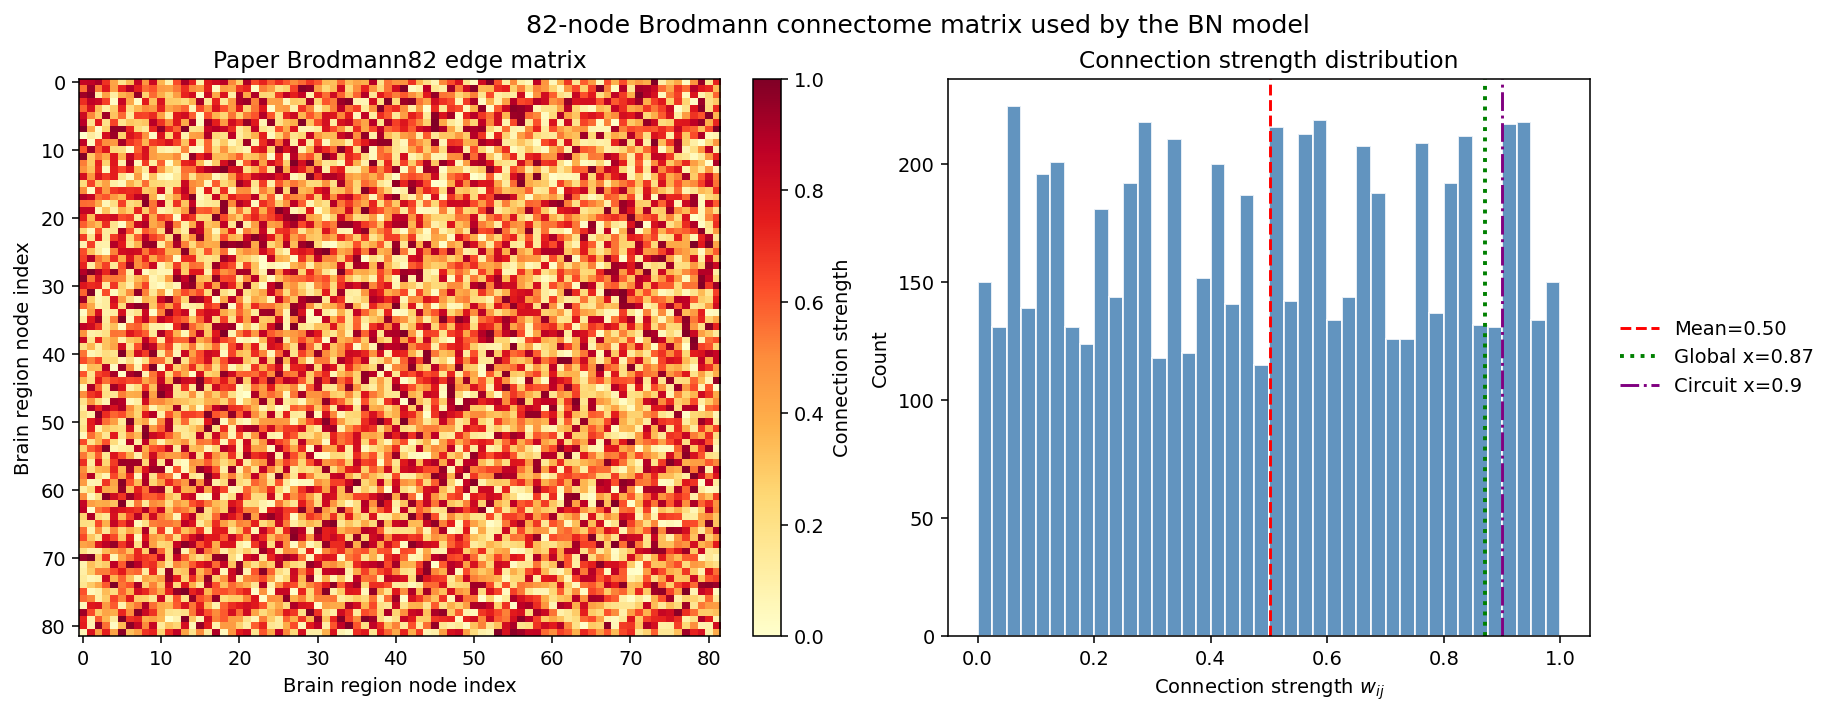

In [3]:
fig, axes = brain_bn.plot_connectome_overview(W_paper, X_PAPER, X_CIRCUIT)
display_png(fig)
plt.close(fig)


### 1.2 阈值化与初始状态

连续权重矩阵二值化为

$$A_{ij} = \begin{cases} 1 & \text{if } w_{ij} \geq x \\ 0 & \text{otherwise} \end{cases}$$

参数对齐如下：

- `X_PAPER = 0.87`：全局动力学、DC 和 $\Phi^{EID}$ 主分析。
- `X_CIRCUIT = 0.90`：论文涌现回路主例。
- `A_main = A_paper`：保留原始论文矩阵方向，不做额外拟合分支。

Action-Execution 初始状态使用论文给出的 16 个 BrainMap 节点；多初始条件分析保留该初始状态，并加入 HCP Motor、Working Memory、Language、Emotion、Gambling/Reward、Social、Relational 七类 task-fMRI 行为域的 Brodmann82 代理初始状态。

注意：Emotion 与 Gambling/Reward 的真实任务网络包含杏仁核、纹状体、丘脑等皮层下结构；当前 82-node Brodmann atlas 不含这些区域，因此这里采用皮层 Brodmann82 proxy，而不是精确 HCP 激活 mask。


## 2. 同步布尔网络动力学

采用同步更新（CRBN）：所有节点在同一时间步同时更新。

$$\sigma_i(t) = \sum_j A_{ij} x_j(t), \qquad x_i(t+1)=1 \;\text{iff}\; a < \sigma_i(t) < b.$$

下面保留论文复现主线，并把实验扫描使用的下阈值暴露为 `A_EXPERIMENT`（默认 1）。raster scan 扫描 `b=1..13`，Table 3 周期对照对象 `paper_phase_results` 仍保留论文的 `a=1..3` 全表。


In [4]:
A_REF, B_REF = 1, 4
traj_demo = run_boolean_network(A_main, s0, a=A_REF, b=B_REF, T=500)
active = traj_demo.sum(axis=1)

paper_phase_results = brain_bn.compute_paper_phase_results(A_main, s0)
paper_circuit_results = brain_bn.compute_paper_circuit_results(A_circuit, s0)

print(f"Trajectory shape: {traj_demo.shape}  (time steps T+1 x nodes N)")
print(f"Paper global parameters: x={X_MAIN}, a={A_REF}, b={B_REF}")
print(f"Active node range (steps 400-500): [{active[400:].min()}, {active[400:].max()}]")
print(f"Step 500 active nodes: {traj_demo[500].sum()}")
print()
print(f"{'(a,b)':>10} {'Paper T3':>10} {'Python period':>14} {'Final active':>14}")
print('-' * 58)
for a in [1, 2, 3]:
    for b in range(1, 14):
        row = paper_phase_results[(a, b)]
        paper_s = str(row['paper_period']) if row['paper_period'] is not None else 'No period'
        py_s = str(row['python_period']) if row['python_period'] is not None else 'No period'
        print(f"  ({a:2d},{b:2d}) {paper_s:>10} {py_s:>14} {row['final_active']:>14}")
print()
print("Paper circuit summary:", paper_circuit_results)


Trajectory shape: (501, 82)  (time steps T+1 x nodes N)
Paper global parameters: x=0.87, a=1, b=4
Active node range (steps 400-500): [6, 47]
Step 500 active nodes: 46

     (a,b)   Paper T3  Python period   Final active
----------------------------------------------------------
  ( 1, 1)  No period              1              0
  ( 1, 2)        199              1              0
  ( 1, 3)        248              1              0
  ( 1, 4)         48              1              0
  ( 1, 5)         35              1              0
  ( 1, 6)          6            525             63
  ( 1, 7)          4             74             59
  ( 1, 8)          2             20             69
  ( 1, 9)          2              6             77
  ( 1,10)          2              4             77
  ( 1,11)          2              2             74
  ( 1,12)          2              1             68
  ( 1,13)          1              1             69
  ( 2, 1)          1              1              0
  ( 2, 

IC 1: Paper Action-Execution - done
IC 2: All-zeros (silent) - done
IC 3: HCP Motor - done
IC 4: HCP Working Memory - done
IC 5: HCP Language - done
IC 6: HCP Emotion - done
IC 7: HCP Gambling/Reward - done
IC 8: HCP Social - done
IC 9: HCP Relational - done

All 9 initial-condition scans complete.
Color key: 0 = silent = light gray  |  1 = active = dark blue-gray


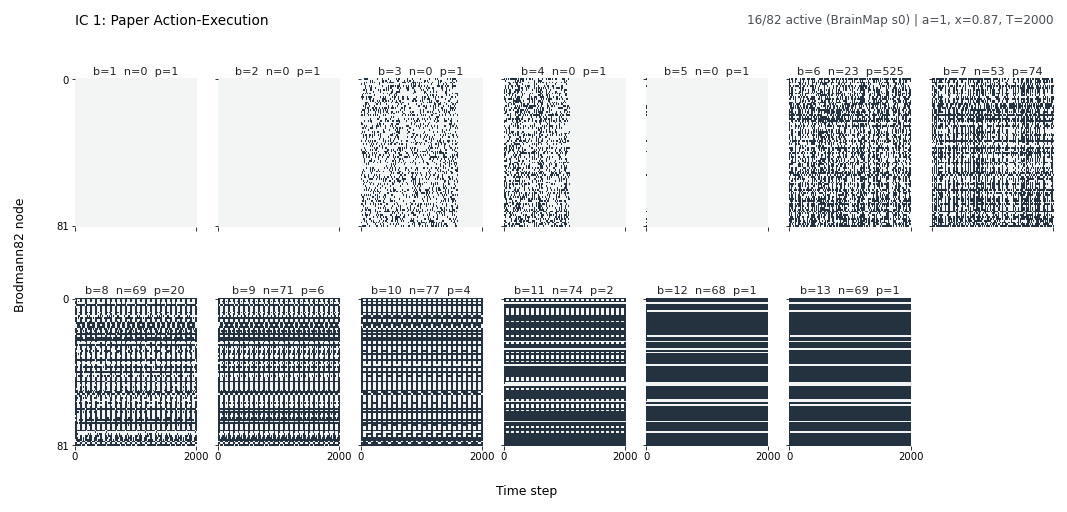

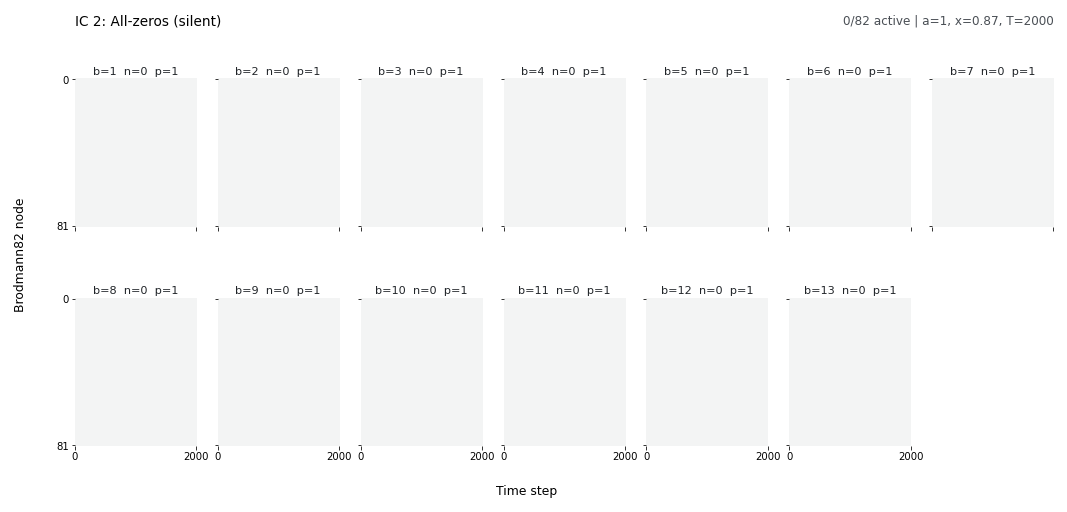

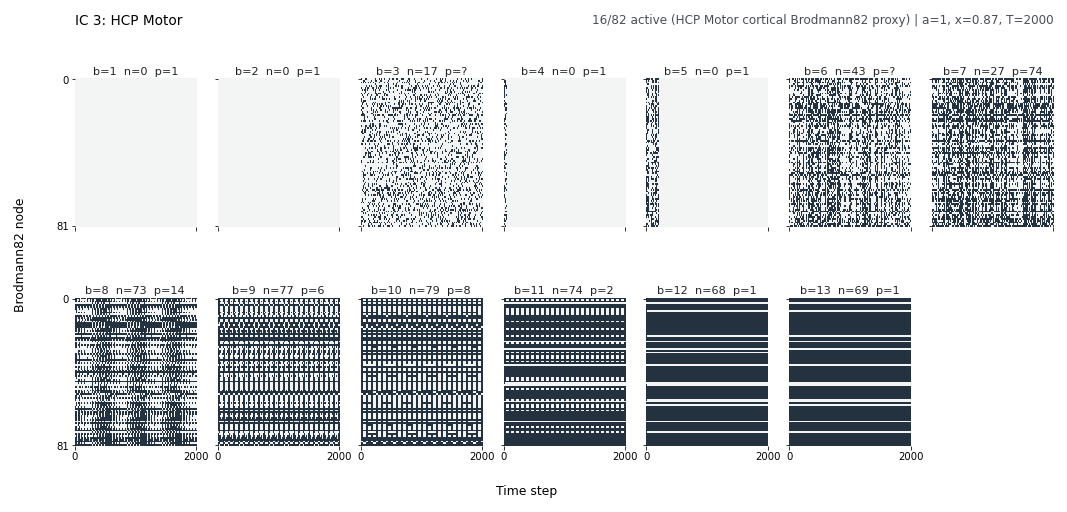

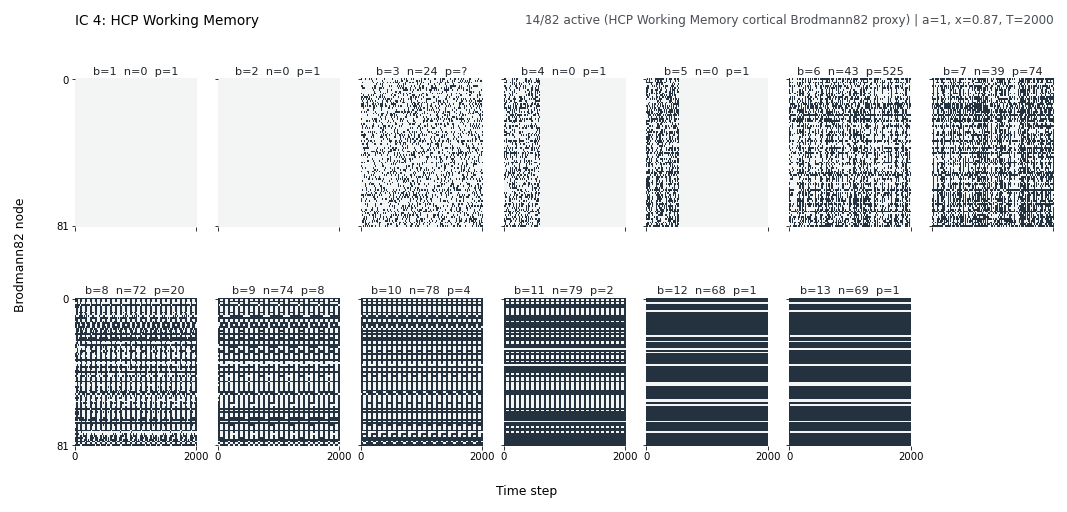

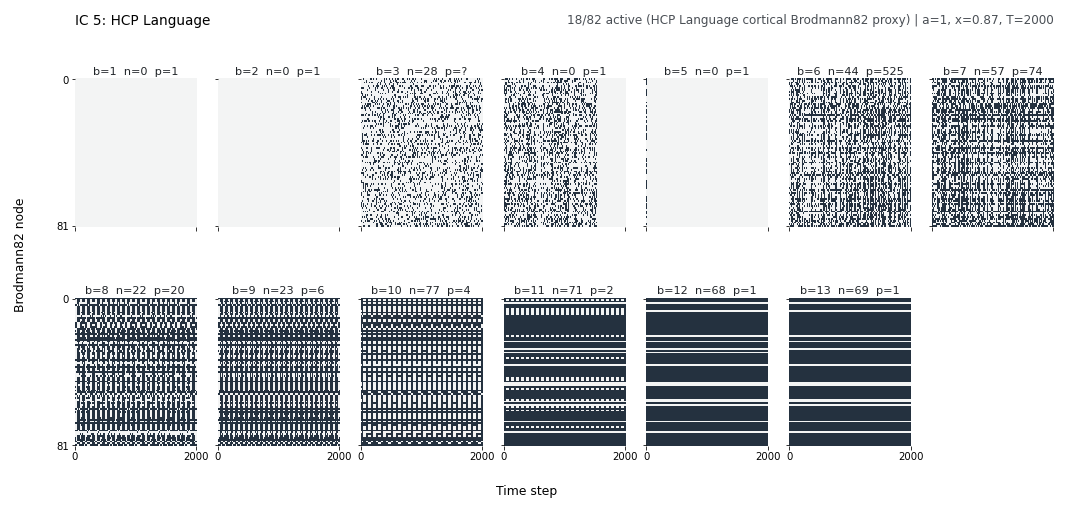

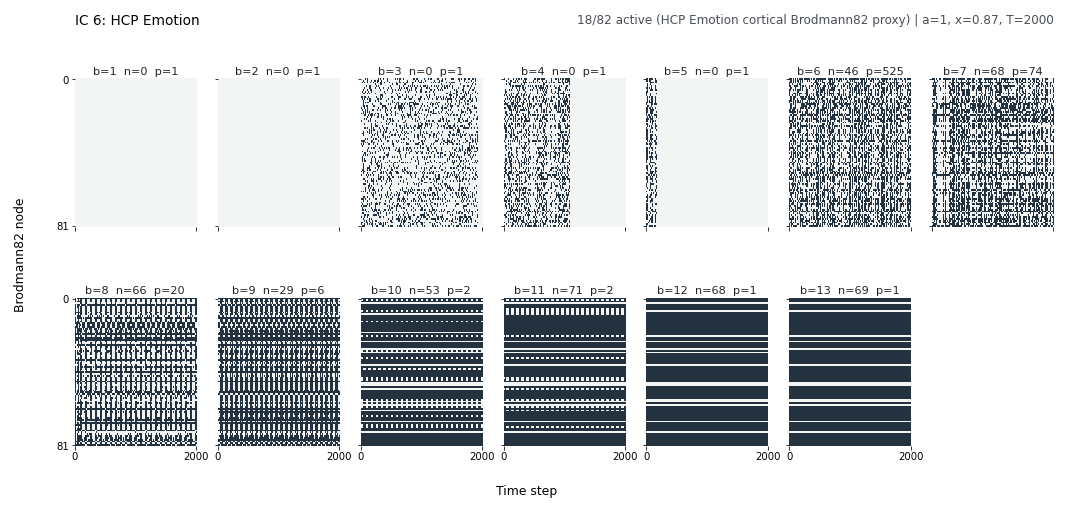

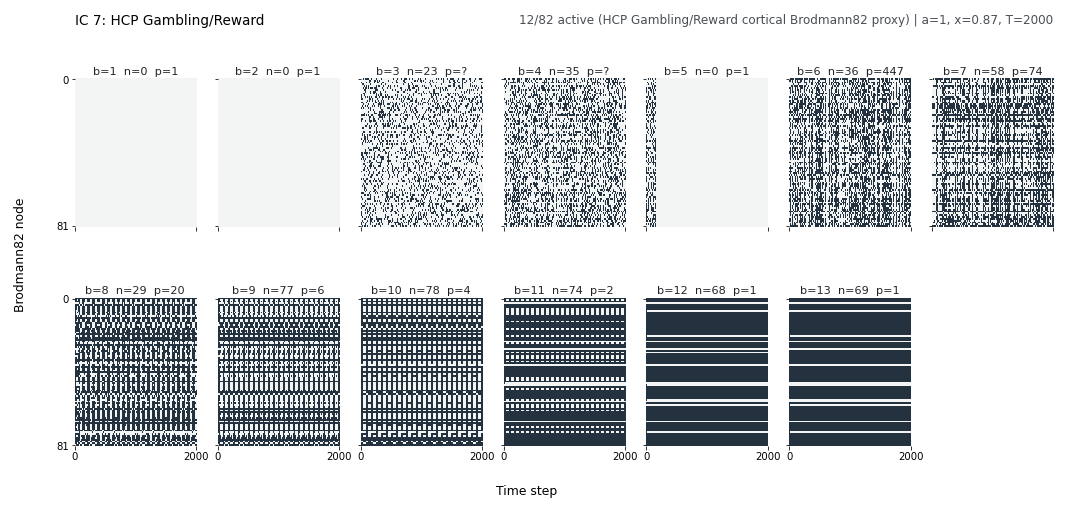

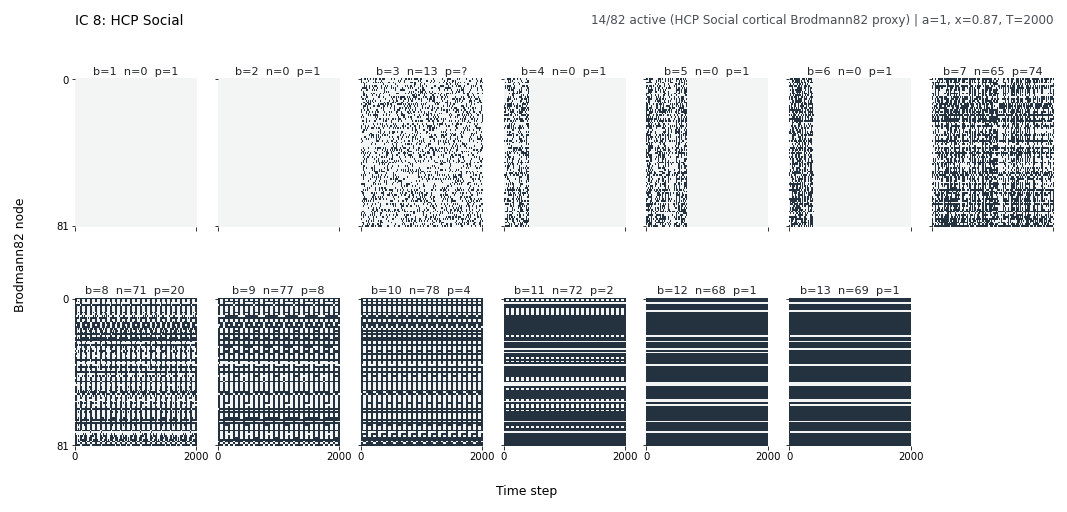

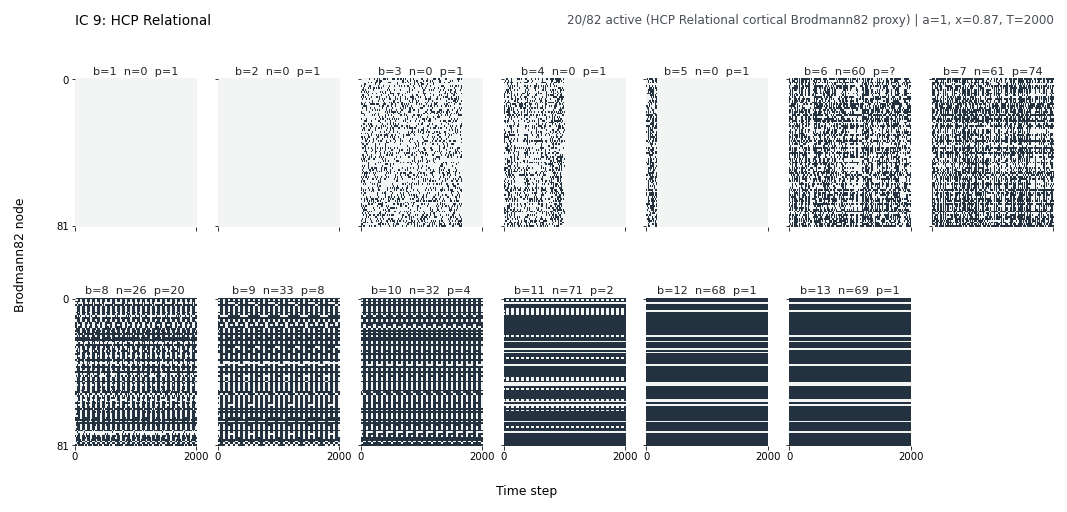

In [5]:
T_SCAN = 2000
INIT_CONDITIONS = brain_bn.make_literature_initial_conditions(s0, include_silent=True)
figures = brain_bn.plot_initial_condition_scan(
    A_main,
    s0,
    X_MAIN,
    a_fixed=A_EXPERIMENT,
    T_scan=T_SCAN,
    initial_conditions=INIT_CONDITIONS,
)
for fig in figures:
    display_png(fig)
    plt.close(fig)


### 2.3 Table 3 / Fig. 5 复现说明

Table 3 周期用完整重复状态检测估算，而不是只比较尾部第一帧。Fig. 5 的完全复现仍受论文未公开 Mathematica 实现细节影响；此前的阈值比较符、矩阵方向、自连接和闭/开区间探针结果保存在 `exp/cache/boolean_brain_dynamics_fig5_variant_scores.csv`。


## 3. Downward Causation 的 $b$ 轴剖面

固定 `a=A_EXPERIMENT`（默认 1）和 `x=0.87`，扫描 `b=2..13`。

- **平均 DC**：对 82 个目标节点分别计算局部 mean-field open-subgraph 的 $DC_j$，再在文献定义的多个非零初始条件上取平均。
- **典型相态标签**：对 Paper Action-Execution 加 HCP 七类 task-fMRI 行为域初始条件分别分类，按多数投票得到 `phase`。如果票数相同，优先保留动态相（`complex > chaotic > ordered > dead`），避免单个 dead basin 掩盖边界动力学。

这样可以检验相态判断是否依赖单一行为域初始状态；表中的 `phase_counts` 给出每个 `b` 的投票依据。

缓存文件为 `exp/cache/boolean_brain_dynamics_literature_ic_dc_profile.csv` 和配套 JSON，避免重复计算多初始条件 DC。


In [6]:
FORCE_RECOMPUTE = False
B_PROFILE = list(range(2, 14))

profile_rows, dc_profile_details, dc_cache_info = brain_bn.load_or_compute_dc_profile(
    A_main,
    s0,
    _cache_dir,
    force_recompute=FORCE_RECOMPUTE,
    a_fixed=A_EXPERIMENT,
    b_values=B_PROFILE,
)

dc_profile_df = pd.DataFrame(profile_rows)
cache_status = "loaded" if dc_cache_info["loaded_from_cache"] else "computed"
print(f"DC profile {cache_status}: {dc_cache_info['csv_path']}")
print(f"Phase rule: {dc_profile_details['phase_rule']}")
print(f"Initial conditions used for typical phase: {dc_profile_details['initial_condition_labels']}")

display_cols = ["b", "phase", "period", "mean_final_active", "tail_mean_active", "mean_dc", "phase_counts", "phase_vote_count"]
dc_profile_df[display_cols].style.format({
    "mean_final_active": "{:.1f}",
    "tail_mean_active": "{:.1f}",
    "mean_dc": "{:.3f}",
})


DC profile loaded: /Users/yangmingzhe/Desktop/code/github/EISyn/exp/cache/boolean_brain_dynamics_literature_ic_dc_profile.csv
Phase rule: vote across Paper Action-Execution plus seven nonzero HCP task-domain initial conditions; dead if tail all zero; ordered if period<=10; complex if period>10 or no-period tail mean activity >= 0.35*N; ties prefer dynamic phases over dead
Initial conditions used for typical phase: ['IC 1: Paper Action-Execution', 'IC 3: HCP Motor', 'IC 4: HCP Working Memory', 'IC 5: HCP Language', 'IC 6: HCP Emotion', 'IC 7: HCP Gambling/Reward', 'IC 8: HCP Social', 'IC 9: HCP Relational']


,b,phase,period,mean_final_active,tail_mean_active,mean_dc,phase_counts,phase_vote_count
0,2,dead,1.000000,0.0,0.0,0.000,"{'dead': 8, 'chaotic': 0, 'complex': 0, 'ordered': 0}",8
1,3,chaotic,nan,20.0,20.0,0.156,"{'dead': 0, 'chaotic': 8, 'complex': 0, 'ordered': 0}",8
2,4,chaotic,nan,18.4,18.6,0.318,"{'dead': 1, 'chaotic': 5, 'complex': 0, 'ordered': 2}",8
3,5,dead,1.000000,0.0,4.2,0.440,"{'dead': 6, 'chaotic': 0, 'complex': 0, 'ordered': 2}",8
4,6,complex,nan,28.8,32.1,0.470,"{'dead': 0, 'chaotic': 0, 'complex': 7, 'ordered': 1}",8
5,7,complex,74.000000,46.4,41.9,0.412,"{'dead': 0, 'chaotic': 0, 'complex': 8, 'ordered': 0}",8
6,8,complex,20.000000,49.5,47.1,0.316,"{'dead': 0, 'chaotic': 0, 'complex': 8, 'ordered': 0}",8
7,9,ordered,6.000000,57.6,51.4,0.222,"{'dead': 0, 'chaotic': 0, 'complex': 0, 'ordered': 8}",8
8,10,ordered,4.000000,69.0,56.1,0.143,"{'dead': 0, 'chaotic': 0, 'complex': 0, 'ordered': 8}",8
9,11,ordered,2.000000,73.2,63.5,0.094,"{'dead': 0, 'chaotic': 0, 'complex': 0, 'ordered': 8}",8


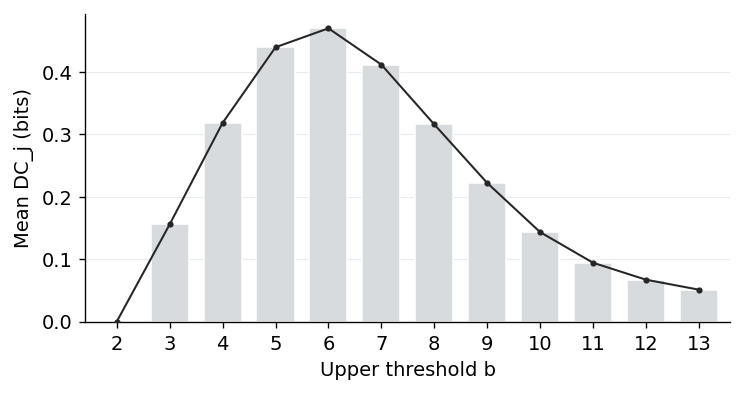

In [7]:
fig, ax = brain_bn.plot_dc_profile(profile_rows)
display_png(fig)
plt.close(fig)


### 3.1 结果解读

当前剖面只展示 `mean_dc`：它衡量全网络对单节点的平均向下因果。图中不再用颜色编码相态；相态判断保留在上方表格的 `phase` 和 `phase_counts` 中。

相态标签采用多初始条件投票规则：对 Paper Action-Execution 加 HCP 七类 task-fMRI 行为域逐一运行轨迹分类，然后按多数投票得到 `phase`。单条轨迹中，tail 全零为 `dead`；检测到周期且 `period <= 10` 为 `ordered`；检测到长周期 `period > 10` 为 `complex`。

`chaotic` 与 `complex` 的区别只在未检测到周期时使用：若尾部平均激活数 `tail_mean_active >= 0.35N`，说明系统保持高维、持续活跃的长瞬态，归为 `complex`；若未检测到周期且尾部平均激活低于该阈值，则归为 `chaotic`。平票时按 `complex > chaotic > ordered > dead` 保留动态相。

读图时重点看三点：

1. **相态投票是否集中。** `phase_counts` 可以直接检查某个 `b` 的标签是否由多数行为域支持，还是来自平票优先级。
2. **DC 峰值位置。** 比较 `mean_dc` 峰值与 typical phase，判断高反事实因果响应是否出现在复杂/混沌边缘附近。
3. **有序区下降。** 当周期变短或进入固定点，`mean_dc` 通常会下降，说明系统虽然更可预测，但整体对单节点的不可约影响减弱。

需要注意：DC 是 counterfactual/interventional 指标，即使某个 observed trajectory 最终 dead，在局部状态干预下仍可能有较高的因果响应。因此 `b=5` 的高 DC 应解释为规则结构的反事实潜力，而不是稳态活跃动力学。


## 4. 总结

本 notebook 已合并为一个主报告：

1. **连接矩阵**：直接使用 `Edge_Brodmann82.edge` 作为 `W_paper`，保留论文阈值 `x=0.87` 与回路阈值 `x=0.90`。
2. **全局动力学**：保留 `a=1, b=1..13` 的多初始条件 raster scan，并保留 Table 3 对照对象 `paper_phase_results`。
3. **DC 剖面**：新增 `dc_profile_df`，比较 `b=2..13` 下的平均 DC，并用多初始条件 typical phase 给每个 `b` 标色。

长函数、相态投票、缓存读写和绘图细节都放在 `exp/boolean_brain_dynamics_support.py`；notebook 只保留参数、主输出和解释。
